# Регрессионный анализ
## Инициализация окружения

In [2]:
from scipy.stats import uniform, norm, t, f, randint
from sklearn.decomposition import PCA
from regression import R_square, RSS, TSS, LinearRegression
from numpy.random import MT19937, RandomState, SeedSequence
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# task init
SEED = 2
GENERATOR = RandomState(MT19937(SeedSequence(SEED)))

## Загрузка данных

In [4]:
DATA = pd.read_csv("data.csv")

# categorial processing
DATA = pd.get_dummies(DATA, prefix="№", columns=["№"], dtype=int)

DATA.head()

,%,№_1,№_2,№_3,№_4,№_5
0,83,1,0,0,0,0
1,85,1,0,0,0,0
2,84,0,1,0,0,0
3,85,0,1,0,0,0
4,85,0,1,0,0,0


## Построение модели и регрессионный анализ

Раз все признаки лежат в одинаковых пределах $[0, 1]$, нормализация не требуется.

In [5]:
X = DATA.drop("%", axis=1).to_numpy()
Y = DATA["%"].to_numpy()

Будем использовать линейную модель. Чтобы избежать вырождения матрицы $F$, не будем использовать bias.

In [6]:
REGRESSION = LinearRegression(fit_bias=False).fit(X, Y)

### Оценка модели
#### Визуализация

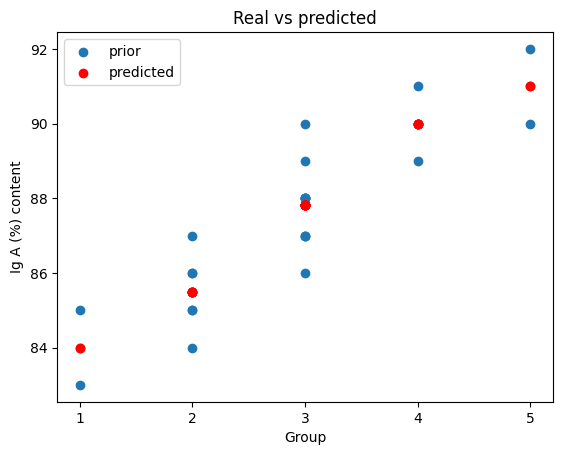

In [7]:
figure, axis = plt.subplots()

axis.scatter(pd.read_csv("data.csv").drop("%", axis=1), Y, label="prior")
axis.scatter(pd.read_csv("data.csv").drop("%", axis=1), REGRESSION.predict(X), c="r", label="predicted")

axis.set_title("Real vs predicted")

axis.set_ylabel("Ig A (%) content")

axis.set_xticks(np.arange(1, 6, 1))
axis.set_xlabel("Group")

plt.legend()

plt.show()


#### Вычисление $R^2$

In [8]:
R_SQUARE = R_square(Y, REGRESSION.predict(X))
RSS_REGRESSION = RSS(Y, REGRESSION.predict(X))
R_SQUARE

np.float64(0.8106060606060606)

$R^2 > 0.7 \Longrightarrow$ большая часть дисперсии отклика объясняется зависимостью от возрастной группы.

### Значимость всей регрессии

$$
H_0: \eta = \epsilon, \newline
H_1: \eta = \Psi\beta + \epsilon
$$

In [9]:
ALPHA = 0.05
delta = R_SQUARE / (1 - R_SQUARE) * (Y.size - REGRESSION.coeff.size) / (REGRESSION.coeff.size - 1)
f(REGRESSION.coeff.size - 1, Y.size - REGRESSION.coeff.size).sf(delta) < ALPHA

np.True_

Регрессия значима.

### Проверка значимости коэффициентов

Проверим эту гипотезу против следующей альтернативы:
$$
H_0: \beta_i = 0, \newline
H_1: \beta_i \ne 0, \newline
i = 1, ..., 5
$$
С учётом того, что
$$
\Delta = {\beta_i \over \sqrt{RSS \cdot F^{-1}_{ii}}} \cdot \sqrt{N-P} \sim t(N - P)
$$
получаем критерий.

In [10]:
delta = REGRESSION.coeff / np.sqrt(RSS(Y, REGRESSION.predict(X)) * np.diag(REGRESSION.Fisher_matrix)) * np.sqrt(Y.size - REGRESSION.coeff.size)

np.sort(2 * t(Y.size - REGRESSION.coeff.size).sf(delta)) < ALPHA / np.arange(5, 0, -1)

array([ True,  True,  True,  True,  True])

С учётом поправки Холма-Бонферони, все гипотезы отвергнуты, а все коэффициенты - значимы.

### Попарное сравнение средних

Проверим эту гипотезу против следующей альтернативы:
$$
H_0: \beta_i = \beta_j, \newline
H_1: \beta_i \ne \beta_j, \newline
i, j = 1, ..., 5; i \ne j
$$
Известно, что
$$
\tilde\beta_i \sim N(\beta_i, \sigma^2 F^{-1}_{ii}), \newline
\tilde\beta_j \sim N(\beta_j, \sigma^2 F^{-1}_{jj}), \newline
$$
при этом
$$
\eta = \tilde\beta_i - \tilde\beta_j
$$
в общем случае не является независимой!

Из свойств нормального распределения:
$$
\eta \sim N(\beta_i - \beta_j, \sigma^2 (F^{-1}_{ii} + F^{-1}_{jj} - 2 F^{-1}_{ij})).
$$

In [11]:
REGRESSION.coeff

array([84.        , 85.5       , 87.81818182, 90.        , 91.        ])

In [27]:
import tqdm

delta = []

for i in tqdm.tqdm(range(REGRESSION.coeff.size)):
    delta.append([])
    for j in tqdm.tqdm(range(REGRESSION.coeff.size)):
        delta[i].append(0)
        if j <= i:
            delta[i][j] = -np.nan
            continue
        delta[i][j] = (
            (REGRESSION.coeff[i] - REGRESSION.coeff[j]) * np.sqrt(Y.size - REGRESSION.coeff.size) /
            np.sqrt(REGRESSION.Fisher_matrix[i][i] + REGRESSION.Fisher_matrix[j][j] - 2 * REGRESSION.Fisher_matrix[i][j])
        )



100%|██████████| 5/5 [00:00<00:00, 168.53it/s]


In [29]:
delta = np.array(delta)

np.sort(2 * t(Y.size - REGRESSION.coeff.size).sf(delta).flatten())[:10] < ALPHA / np.arange(10, 0, -1)

array([False, False, False, False, False, False, False, False, False,
       False])

Нет оснований отвергнуть гипотезу равенства средних.